In [12]:
import pandas as pd

df = pd.read_parquet("../data/processed/tweets_ai_sentiment_hf.parquet")

print("=== SHAPE ===")
print(df.shape)

print("\n=== COLUMNAS ===")
print(df.columns.tolist())

print("\n=== DISTRIBUCIÓN POR AÑO ===")
print(df.groupby(df["created_at"].dt.year).size())

print("\n=== SENTIMIENTO GLOBAL ===")
print(df["sentiment_label_hf"].value_counts(normalize=True).round(3))

print("\n=== SECTORES DISPONIBLES ===")
if "sector" in df.columns:
    print(df["sector"].value_counts())
else:
    print("columna 'sector' no existe")

print("\n=== COLUMNA has_url ===")
if "has_url" in df.columns:
    print(df["has_url"].value_counts())
else:
    print("columna 'has_url' no existe")

=== SHAPE ===
(861116, 27)

=== COLUMNAS ===
['id', 'conversation_id', 'created_at', 'date', 'time', 'timezone', 'tweet', 'language', 'urls', 'photos', 'replies_count', 'retweets_count', 'likes_count', 'hashtags', 'cashtags', 'retweet', 'quote_url', 'video', 'thumbnail', 'dominios_url', 'tipo_fuente_url', 'tweet_clean', 'tweet_clean_filt', 'num_palabras_filt', 'tweet_hf', 'sentiment_label_hf', 'sentiment_score_hf']

=== DISTRIBUCIÓN POR AÑO ===
created_at
2017    313319
2018    223002
2019    212739
2020     80734
2021     31322
dtype: int64

=== SENTIMIENTO GLOBAL ===
sentiment_label_hf
neutral     0.702
positive    0.228
negative    0.070
Name: proportion, dtype: float64

=== SECTORES DISPONIBLES ===
columna 'sector' no existe

=== COLUMNA has_url ===
columna 'has_url' no existe


In [30]:
df.head()

,id,conversation_id,created_at,date,time,timezone,tweet,language,urls,photos,...,dominios_url,tipo_fuente_url,tweet_clean,tweet_clean_filt,num_palabras_filt,tweet_hf,sentiment_label_hf,sentiment_score_hf,year,has_url
0,826580756675694720,826580756675694720,2017-01-31 18:59:44,2017-01-31,18:59:44,-400,What topic could spark human dialogue on AI? A...,en,[https://blog.hubspot.com/marketing/artificial...,[],...,[blog.hubspot.com],[news],what topic could spark human dialogue on ai ar...,what topic could spark human dialogue on ai ar...,13,What topic could spark human dialogue on AI? A...,neutral,0.722622,2017,True
1,826580719921152000,826580719921152000,2017-01-31 18:59:35,2017-01-31,18:59:35,-400,I think #ArtificialIntelligence will augment h...,en,[http://bit.ly/2bWb1ly],[],...,[bit.ly],[other],i think artificialintelligence will augment hu...,i think will augment humanity way before it di...,10,I think #ArtificialIntelligence will augment h...,positive,0.562817,2017,True
2,826580631366700928,826580631366700928,2017-01-31 18:59:14,2017-01-31,18:59:14,-400,What Managers Need to Know About Artificial In...,en,[http://mitsmr.com/2klQ17D],[],...,[mitsmr.com],[news],what managers need to know about artificial in...,what managers need to know about artificial in...,9,What Managers Need to Know About Artificial In...,neutral,0.845438,2017,True
3,826580578954780672,826580578954780672,2017-01-31 18:59:01,2017-01-31,18:59:01,-400,4 ways Artificial Intelligence changes the gam...,en,[http://bit.ly/2koUCIB],[],...,[bit.ly],[other],4 ways artificial intelligence changes the gam...,4 ways artificial intelligence changes the gam...,9,4 ways Artificial Intelligence changes the gam...,neutral,0.593140,2017,True
4,826580577457287040,826580577457287040,2017-01-31 18:59:01,2017-01-31,18:59:01,-400,Artificial Intelligence can Shape the Future o...,en,[https://www.youtube.com/watch?v=NQefTsrSjJY],[],...,[youtube.com],[social],artificial intelligence can shape the future o...,artificial intelligence can shape the future o...,9,Artificial Intelligence can Shape the Future o...,positive,0.610682,2017,True


In [18]:
# ============================================================
# CELDA 1 — Imports y carga
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings("ignore")

SENTIMENT_COLORS = {   
    "negative": "#e74c3c",
    "neutral":  "#95a5a6",
    "positive": "#2ecc71",
}

df = pd.read_parquet("../data/processed/tweets_ai_sentiment_hf.parquet")
df["year"] = df["created_at"].dt.year
df["has_url"] = df["urls"].apply(lambda x: len(x) > 0)

print(f"Total tweets: {len(df):,}")
print(f"Con URL:    {df['has_url'].sum():,} ({df['has_url'].mean():.1%})")
print(f"Sin URL:    {(~df['has_url']).sum():,} ({(~df['has_url']).mean():.1%})")

Total tweets: 861,116
Con URL:    737,727 (85.7%)
Sin URL:    123,389 (14.3%)


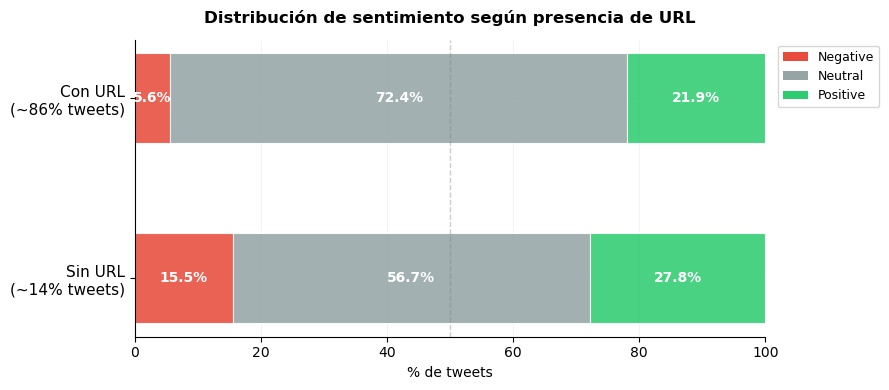

Saved: ../figures/04_url_vs_nourl_sentimiento.png


In [31]:
# ============================================================
# CELDA 2 — G1: URL vs no-URL — justificación metodológica
# ============================================================
# Este es el gráfico que justifica quedarnos con tweets sin URL.
# Muestra empíricamente que la presencia de URL colapsa el sentimiento
# hacia neutral, eliminando la señal de opinión que nos interesa.

url_sent = (
    df.groupby(["has_url", "sentiment_label_hf"])
    .size()
    .rename("n")
    .reset_index()
)
url_sent["total"] = url_sent.groupby("has_url")["n"].transform("sum")
url_sent["pct"] = url_sent["n"] / url_sent["total"] * 100

# Pivot para plotting
pivot = url_sent.pivot(index="has_url", columns="sentiment_label_hf", values="pct")
pivot = pivot[["negative", "neutral", "positive"]]
pivot.index = ["Sin URL\n(~14% tweets)", "Con URL\n(~86% tweets)"]

fig, ax = plt.subplots(figsize=(9, 4))

y      = np.arange(len(pivot))
height = 0.5
left   = np.zeros(len(pivot))

for sentiment, color in SENTIMENT_COLORS.items():
    vals = pivot[sentiment].values
    bars = ax.barh(y, vals, height=height, left=left,
                   color=color, alpha=0.88, edgecolor="white", linewidth=0.8)
    for i, (v, l) in enumerate(zip(vals, left)):
        if v > 5:
            ax.text(l + v / 2, i, f"{v:.1f}%",
                    ha="center", va="center",
                    fontsize=10, color="white", fontweight="bold")
    left += vals

ax.axvline(50, color="gray", linewidth=1.0, linestyle="--", alpha=0.4)
ax.set_yticks(y)
ax.set_yticklabels(pivot.index, fontsize=11)
ax.set_xlabel("% de tweets", fontsize=10)
ax.set_xlim(0, 100)
ax.set_title(
    "Distribución de sentimiento según presencia de URL",
    fontsize=12, fontweight="bold", pad=12
)
legend_elements = [Patch(facecolor=SENTIMENT_COLORS[s], label=s.capitalize())
                   for s in ["negative", "neutral", "positive"]]
ax.legend(handles=legend_elements, 
          loc="upper left", 
          bbox_to_anchor=(1.01, 1),
          fontsize=9, framealpha=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../figures/04_url_vs_nourl_sentimiento.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ../figures/04_url_vs_nourl_sentimiento.png")

In [24]:
# ============================================================
# CELDA 3 — Decisión metodológica + filtro
# ============================================================
# A partir de aquí trabajamos SOLO con tweets sin URL.
# Justificación: los tweets con URL son mayoritariamente actos de
# difusión de contenido (noticias, artículos), no expresión de opinión.
# Su sentimiento neutro (~75%) no refleja percepción pública sino
# comportamiento de sharing. Para medir cómo evoluciona la percepción
# real de la IA, el subconjunto relevante son los tweets sin URL.

df_op = df[~df["has_url"]].copy()
print(f"Tweets de opinión (sin URL): {len(df_op):,}")
print(f"\nDistribución por año:")
print(df_op.groupby("year").size())
print(f"\nSentimiento global (sin URL):")
print(df_op["sentiment_label_hf"].value_counts(normalize=True).round(3))

Tweets de opinión (sin URL): 123,389

Distribución por año:
year
2017    29290
2018    33721
2019    37739
2020    15248
2021     7391
dtype: int64

Sentimiento global (sin URL):
sentiment_label_hf
neutral     0.567
positive    0.278
negative    0.155
Name: proportion, dtype: float64


In [32]:
print("Distribución sectorial:")
print(df_op["sector"].value_counts())
print(f"\nCobertura: {(df_op['sector'] != 'other').mean():.1%} tweets asignados a un sector")

Distribución sectorial:
sector
other         101401
employment     12059
education       9929
Name: count, dtype: int64

Cobertura: 17.8% tweets asignados a un sector


In [55]:
# Términos técnicos de ML que contienen "learn" pero NO son educación
ML_NOISE = [
    "machine learning", "deep learning", "reinforcement learning",
    "transfer learning", "unsupervised learning", "supervised learning",
    "federated learning", "representation learning", "online learning algorithm",
    "learning algorithm", "learning model", "learning system",
    "learning rate", "learning curve", "neural network learning", "machinelearn", "deeplearn"
]

SECTOR_KEYWORDS = {
    "education": [
        "school", "student", "teacher", "classroom", "university",
        "college", "professor", "pupil", "educator", "faculty",
        "education", "curriculum", "academic", "degree",
        "homework", "tutoring", "exam", "thesis", "literacy",
        "e-learning", "elearning", "online course", "grade",
        "teach", "grading", "cheat", "plagiar",
        "personalized learning", "adaptive learning",
        "ai in education", "ai for education",
        "reskill", "upskill",
        # Reintroducidos con exclusión de ML técnico:
        "learn", "learning", "study", "training", "skills",
    ],
    "employment": [
        # Quitar "work" suelto — demasiado genérico
        "worker", "workers", "workforce", "workplace",
        "work from home", "work-life", "at work", "out of work",
        "jobs at risk", "job loss", "job market", "job creation",
        "job", "jobs", "employ", "unemploy", "occupation",
        "profession", "career", "labor", "labour",
        "automat", "replac", "displac", "outsourc",
        "laid off", "layoff", "downsiz", "redundan",
        "salary", "wage", "income", "earn ",
        "hire", "hiring", "firing", "recruit",
        "gig economy", "freelan", "remote work",
        "white collar", "blue collar", "robot",
        "future of work",],
}

def assign_sector(text):
    if not isinstance(text, str):
        return "other"
    text_lower = text.lower()
    
    # Primero employment (prioridad)
    if any(kw in text_lower for kw in SECTOR_KEYWORDS["employment"]):
        return "employment"
    
    # Para education: verificar keywords pero excluir ML técnico
    if any(kw in text_lower for kw in SECTOR_KEYWORDS["education"]):
        # Si contiene un término de ML técnico, no es educación
        if any(noise in text_lower for noise in ML_NOISE):
            return "other"
        return "education"
    
    return "other"

df_op["sector"] = df_op["tweet_clean_filt"].apply(assign_sector)

print("Distribución sectorial:")
print(df_op["sector"].value_counts())
print(f"\nCobertura: {(df_op['sector'] != 'other').mean():.1%} tweets asignados a un sector")

Distribución sectorial:
sector
other         101258
employment     15499
education       6632
Name: count, dtype: int64

Cobertura: 17.9% tweets asignados a un sector


In [56]:
# Muestra aleatoria de 10 tweets de cada sector para validar calidad
import random

for sector in ["education", "employment"]:
    print(f"\n=== MUESTRA {sector.upper()} ===")
    sample = df_op[df_op["sector"] == sector]["tweet_clean_filt"].sample(10, random_state=42).tolist()
    for i, t in enumerate(sample, 1):
        print(f"{i}. {t}")


=== MUESTRA EDUCATION ===
1. here is a usefull showing different methods and areas of application from learning to prediction and its potential
2. we believe that in the cognitive process although learning and retrieval will certainly play a key role sleep is also necessary for artificial intelligence just as it is for biology
3. none of this is hugely novel but it s well argued and illustrated and i learned a lot there is a very interesting chapter on the difficulties of artificial intelligence language tools shedding light on the painstaking nature of ai development but also human language learning
4. artificial intelligence is robbing people of social skills and confidence and in life confidence is key
5. what will happen when an artificial intelligence comes along and renders any educational and vocational achievement by humans as moot
6. with bina48 at in belmont at the first annual emerging technology for good student led conference learning about artificial intelligence great d

In [57]:
print("Distribución sectorial:")
print(df_op["sector"].value_counts())
print(f"\nCobertura: {(df_op['sector'] != 'other').mean():.1%}")

Distribución sectorial:
sector
other         101258
employment     15499
education       6632
Name: count, dtype: int64

Cobertura: 17.9%


In [58]:
df_op.to_parquet("../data/processed/tweets_op_sectored.parquet", index=False)
print("Guardado: tweets_op_sectored.parquet")

Guardado: tweets_op_sectored.parquet


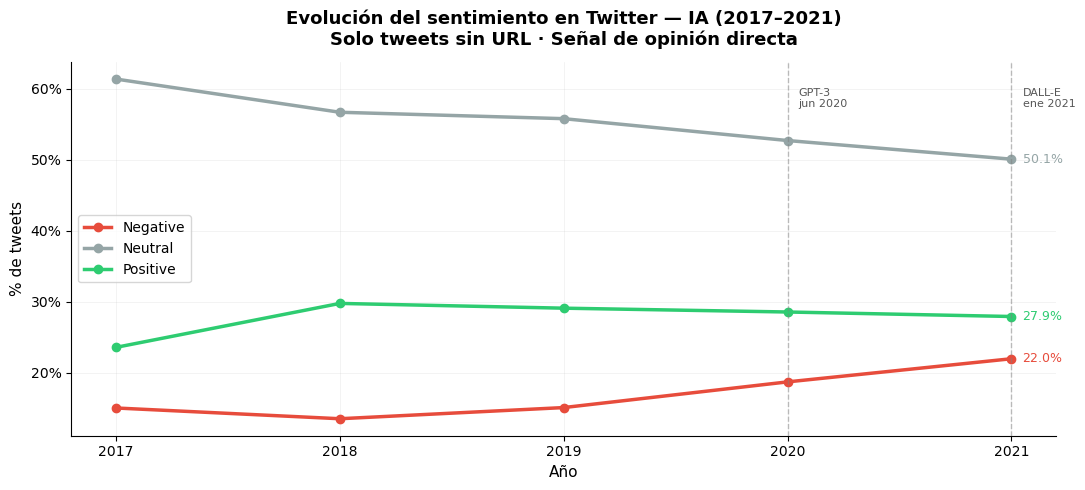

In [59]:
# ============================================================
# CELDA 5 — G2: Evolución global sentimiento Twitter 2017–2021
# ============================================================

HITOS = {
    2020: "GPT-3\njun 2020",
    2021: "DALL-E\nene 2021",
}

trend = (
    df_op
    .groupby(["year", "sentiment_label_hf"])
    .size()
    .rename("n")
    .reset_index()
)
trend["total"] = trend.groupby("year")["n"].transform("sum")
trend["pct"] = trend["n"] / trend["total"] * 100
trend_pivot = trend.pivot(index="year", columns="sentiment_label_hf", values="pct")

fig, ax = plt.subplots(figsize=(11, 5))

for sentiment, color in SENTIMENT_COLORS.items():
    if sentiment in trend_pivot.columns:
        ax.plot(trend_pivot.index, trend_pivot[sentiment],
                marker="o", linewidth=2.5, markersize=6,
                color=color, label=sentiment.capitalize())
        # Anotación del valor final
        last_y = trend_pivot[sentiment].iloc[-1]
        ax.annotate(f"{last_y:.1f}%",
                    xy=(trend_pivot.index[-1], last_y),
                    xytext=(8, 0), textcoords="offset points",
                    fontsize=9, color=color, va="center")

# Anotaciones de hitos
# Sustituye el bloque de hitos por esto:
y_max = trend_pivot.values.max()
for year, label in HITOS.items():
    ax.axvline(year, color="gray", linewidth=1.0, linestyle="--", alpha=0.5)
    ax.text(year + 0.05, y_max * 0.98, label,
            fontsize=8, color="#555555", va="top")

# Y la leyenda:
ax.legend(fontsize=10, framealpha=0.8, loc="lower left")

ax.set_xlabel("Año", fontsize=11)
ax.set_ylabel("% de tweets", fontsize=11)
ax.set_xticks(trend_pivot.index)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_title(
    "Evolución del sentimiento en Twitter — IA (2017–2021)\n"
    "Solo tweets sin URL · Señal de opinión directa",
    fontsize=13, fontweight="bold", pad=12
)
ax.legend(fontsize=10, framealpha=0.8)
ax.grid(alpha=0.2)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../figures/04_evolucion_global_twitter.png", dpi=150, bbox_inches="tight")
plt.show()

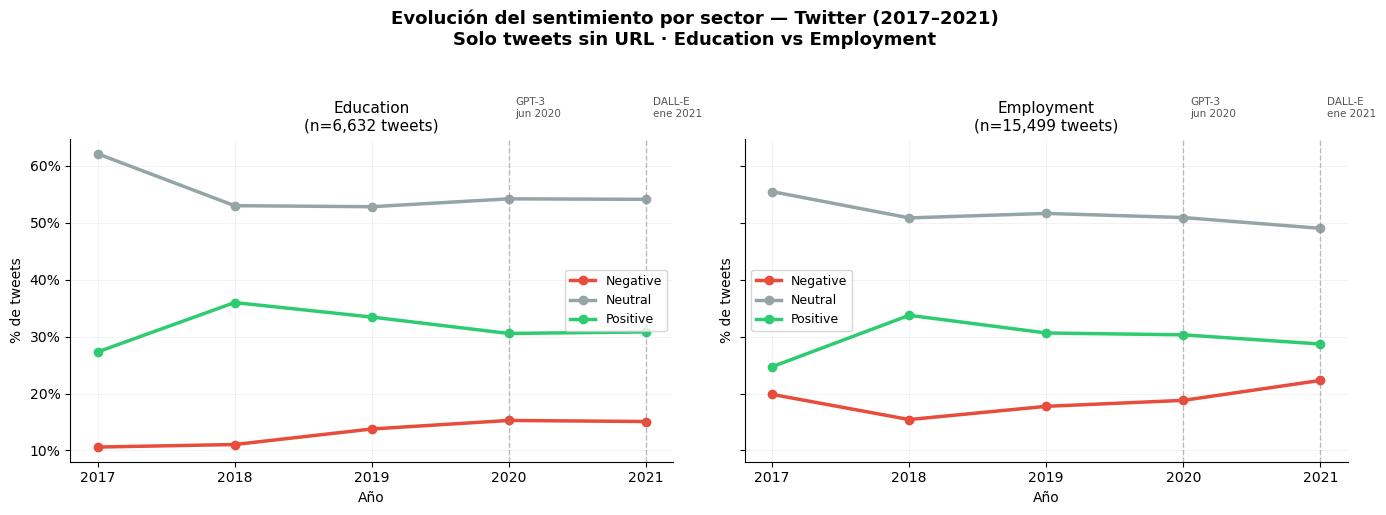

In [60]:
# ============================================================
# CELDA 6 — G3: Evolución sentimiento por sector 2017–2021
# Education vs Employment — misma estructura que YouTube
# ============================================================

df_sect = df_op[df_op["sector"] != "other"].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle(
    "Evolución del sentimiento por sector — Twitter (2017–2021)\n"
    "Solo tweets sin URL · Education vs Employment",
    fontsize=13, fontweight="bold", y=1.02
)

for ax, sector in zip(axes, ["education", "employment"]):
    sub = df_sect[df_sect["sector"] == sector]
    trend_s = (
        sub.groupby(["year", "sentiment_label_hf"])
        .size().rename("n").reset_index()
    )
    trend_s["total"] = trend_s.groupby("year")["n"].transform("sum")
    trend_s["pct"]   = trend_s["n"] / trend_s["total"] * 100
    pivot_s = trend_s.pivot(index="year", columns="sentiment_label_hf", values="pct")

    n_by_year = sub.groupby("year").size()

    for sentiment, color in SENTIMENT_COLORS.items():
        if sentiment in pivot_s.columns:
            ax.plot(pivot_s.index, pivot_s[sentiment],
                    marker="o", linewidth=2.5, markersize=6,
                    color=color, label=sentiment.capitalize())

    for year, label in HITOS.items():
        ax.axvline(year, color="gray", linewidth=1.0, linestyle="--", alpha=0.5)
        ax.text(year + 0.05, 72, label, fontsize=7.5,
                color="#555555", va="top")

    ax.set_title(f"{sector.capitalize()}\n(n={len(sub):,} tweets)", fontsize=11)
    ax.set_xlabel("Año", fontsize=10)
    ax.set_ylabel("% de tweets", fontsize=10)
    ax.set_xticks(pivot_s.index)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(fontsize=9, framealpha=0.8)
    ax.grid(alpha=0.2)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("../figures/04_evolucion_sectores_twitter.png", dpi=150, bbox_inches="tight")
plt.show()

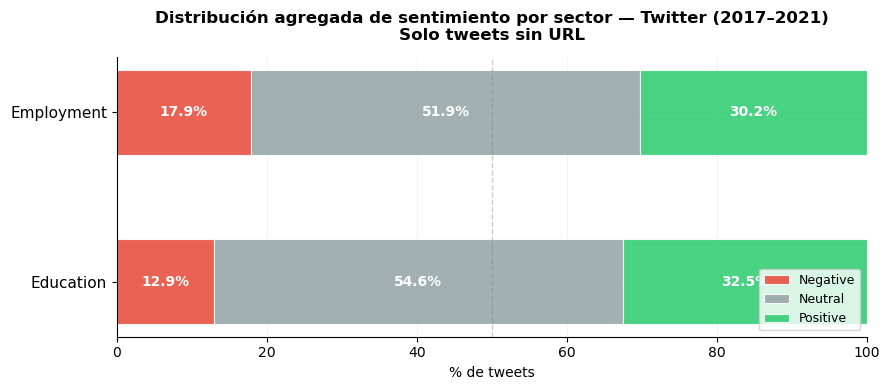

In [61]:
# ============================================================
# CELDA 7 — G4: Distribución agregada por sector
# Para conectar directamente con el 08 cross-platform
# ============================================================

fig, ax = plt.subplots(figsize=(9, 4))

sectors = ["education", "employment"]
sector_labels = ["Education", "Employment"]
y = np.arange(len(sectors))
height = 0.5

agg = (
    df_sect.groupby(["sector", "sentiment_label_hf"])
    .size().rename("n").reset_index()
)
agg["total"] = agg.groupby("sector")["n"].transform("sum")
agg["pct"] = agg["n"] / agg["total"] * 100
agg_pivot = agg.pivot(index="sector", columns="sentiment_label_hf", values="pct")
agg_pivot = agg_pivot.reindex(sectors)[["negative", "neutral", "positive"]]

left = np.zeros(len(sectors))
for sentiment, color in SENTIMENT_COLORS.items():
    vals = agg_pivot[sentiment].values
    ax.barh(y, vals, height=height, left=left,
            color=color, alpha=0.88, edgecolor="white", linewidth=0.8,
            label=sentiment.capitalize())
    for i, (v, l) in enumerate(zip(vals, left)):
        if v > 5:
            ax.text(l + v / 2, i, f"{v:.1f}%",
                    ha="center", va="center",
                    fontsize=10, color="white", fontweight="bold")
    left += vals

ax.axvline(50, color="gray", linewidth=1.0, linestyle="--", alpha=0.4)
ax.set_yticks(y)
ax.set_yticklabels(sector_labels, fontsize=11)
ax.set_xlabel("% de tweets", fontsize=10)
ax.set_xlim(0, 100)
ax.set_title(
    "Distribución agregada de sentimiento por sector — Twitter (2017–2021)\n"
    "Solo tweets sin URL",
    fontsize=12, fontweight="bold", pad=12
)
ax.legend(loc="lower right", fontsize=9, framealpha=0.8)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.2)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("../figures/04_distribucion_sectores_twitter.png", dpi=150, bbox_inches="tight")
plt.show()

In [62]:
# ¿El keyword "work" está capturando tweets genéricos no relacionados con empleo?
mask_work = df_op[df_op["sector"] == "employment"]["tweet_clean_filt"].str.contains(r"\bwork\b", na=False, regex=True)
print(f"Tweets de employment con 'work': {mask_work.sum():,} ({mask_work.mean():.1%})")

print("\nMuestra tweets con 'work' en employment:")
sample = df_op[
    (df_op["sector"] == "employment") & 
    df_op["tweet_clean_filt"].str.contains(r"\bwork\b", na=False, regex=True)
]["tweet_clean_filt"].sample(10, random_state=42).tolist()
for i, t in enumerate(sample, 1):
    print(f"{i}. {t}")

Tweets de employment con 'work': 934 (6.0%)

Muestra tweets con 'work' en employment:
1. rt the future of work is human via intetics
2. 100 a hour minimum wage working alongside artificial intelligence for a 4 hour work week sounds about right
3. first day on next project i and the ai a work that explores artificial intelligence and emotions how do we machine learn algorithms how to break up someone has to crush their heart a billion times
4. more than ever are at work in the us by ty amp cc
5. don funny but in my real life work i am working on what is called rpa robotic process automation this is a couple of rungs lower than artificial intelligence ha life imitates art happy new year to you amp yours your amigo john
6. artificial intelligence can learn and work faster then sending children to school for how many years
7. is definitely artificial intelligence think about it he never misses a day of work seems like he s a robot to me
8. cair welcomes a new employee to work on and accoun

In [63]:
print("Distribución sectorial:")
print(df_op["sector"].value_counts())
print(f"\nCobertura: {(df_op['sector'] != 'other').mean():.1%}")

# Sentimiento por sector para ver si cambia la diferencia
for sector in ["education", "employment"]:
    sub = df_op[df_op["sector"] == sector]
    dist = sub["sentiment_label_hf"].value_counts(normalize=True).round(3)
    print(f"\n{sector.upper()} (n={len(sub):,}):")
    print(dist)

Distribución sectorial:
sector
other         101258
employment     15499
education       6632
Name: count, dtype: int64

Cobertura: 17.9%

EDUCATION (n=6,632):
sentiment_label_hf
neutral     0.546
positive    0.325
negative    0.129
Name: proportion, dtype: float64

EMPLOYMENT (n=15,499):
sentiment_label_hf
neutral     0.519
positive    0.302
negative    0.179
Name: proportion, dtype: float64


In [66]:
# ============================================================
# Top tweets representativos por sector y sentimiento
# Con deduplicación y filtro de calidad
# ============================================================

MIN_WORDS = 8  # tweets muy cortos suelen ser ruido

print("=== TOP TWEETS REPRESENTATIVOS ===\n")

for sector in ["education", "employment"]:
    for sentiment in ["negative", "positive"]:
        sub = df_op[
            (df_op["sector"] == sector) &
            (df_op["sentiment_label_hf"] == sentiment) &
            (df_op["num_palabras_filt"] >= MIN_WORDS)
        ].copy()
        
        # Deduplicar por texto limpio
        sub = sub.drop_duplicates(subset="tweet_clean_filt")
        
        # Ordenar por score y coger top 5
        sub = sub.sort_values("sentiment_score_hf", ascending=False).head(5)
        
        print(f"--- {sector.upper()} · {sentiment.upper()} ---")
        for _, row in sub.iterrows():
            print(f"  [{row['sentiment_score_hf']:.2f}] {row['tweet_hf'][:150]}")
        print()

=== TOP TWEETS REPRESENTATIVOS ===

--- EDUCATION · NEGATIVE ---
  [0.96] Their cluelessness didn't guess to that point.. illiteracy in an ARTIFICIAL INTELLIGENCE age.. sad!!
  [0.96] These guys read and it sounds like a report you give high school. They should know this and be able to speak on it from their knowledge and expertise.
  [0.95] @user @user The sad thing is that you are so obsessed with natural resources you insult by ignoring all of the other industries that are the future of
  [0.95] @user The umbrella term ""artificial intelligence"" turned marketing hype, is unethical, extremely deceptive to the population. The foundation this ma
  [0.95] @user I pity those University students, getting artificial intelligence..🙄😂

--- EDUCATION · POSITIVE ---
  [0.95] We congratulate Mr. @user for getting awarded by @user for using Artificial Intelligence for Good. It was indeed a great learning experience for our t
  [0.95] Congratulations to our December Alumni of the Month— Dovan Ra

In [69]:
# Ver diferencia entre columnas de texto
idx = df_op[
    (df_op["sector"] == "employment") &
    (df_op["sentiment_label_hf"] == "negative")
].index[1]

print("tweet_hf:")
print(df_op.loc[idx, "tweet_hf"])
print("\ntweet_clean_filt:")
print(df_op.loc[idx, "tweet_clean_filt"])
print("\ntweet:")
print(df_op.loc[idx, "tweet"])

tweet_hf:
Even if trump doesn't do it, automation of software development, robotics &amp; artificial intelligence would have replaced low end labour.

tweet_clean_filt:
even if trump doesn t do it automation of software development robotics amp artificial intelligence would have replaced low end labour

tweet:
Even if trump doesn't do it, automation of software development, robotics &amp; artificial intelligence would have replaced low end labour.
